In [4]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import healpix_geo
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from healpix_analyse.make_rectangle import make_healpix_rectangle_from_lonlat
from healpix_analyse.resample import resample_to_latlon_grid
from healpix_analyse.ps import ps

In [6]:
import xarray as xr

ds = xr.open_zarr("/home/jovyan/s2_reflectance_20.zarr")
ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 168MB
Dimensions:   (cells: 4194304)
Coordinates:
    cell_ids  (cells) uint64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
Dimensions without coordinates: cells
Data variables:
    b02       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b03       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b04       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b08       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>

In [7]:
cell_ids = ds["cells"]
cell_ids

<xarray.DataArray 'cells' (cells: 4194304)> Size: 34MB
[4194304 values with dtype=int64]
Coordinates:
    cell_ids  (cells) uint64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
Dimensions without coordinates: cells

In [8]:
# Convert in lat lon
import healpix_geo

ellipsoid = "WGS84" 
level = 20

lon, lat = healpix_geo.nested.healpix_to_lonlat(ds.cell_ids, level, ellipsoid=ellipsoid)

lon_min, lon_max = 2.07, 2.13
lat_min, lat_max = 48.55, 48.6

print(lon_min, lon_max)


2.07 2.13


In [9]:
cell_ids_2D_array = make_healpix_rectangle_from_lonlat(bbox=(lon_min, lat_min, lon_max, lat_max), 
                                                       level=level, 
                                                       ellipsoid=ellipsoid)

lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids_2D_array.flatten(), level, ellipsoid=ellipsoid)

In [10]:
cell_ids_2D_array.shape

(1051, 609)

In [11]:
lon.shape

(640059,)

In [12]:
from cdshealpix import from_ring

In [14]:
import xdggs

ds= ds.dggs.decode({
        "grid_name": "healpix",
        "level": level,
        "indexing_scheme": "nested",
        "ellipsoid": "sphere",
    })

In [15]:
subset = ds.sel(cell_ids=np.sort(from_ring(cell_ids_2D_array.flatten(), depth=level)))
data = subset["b04"].values

In [16]:
from cdshealpix import to_ring

ring_ids = to_ring(subset.cell_ids.values, depth=level)
idx = np.argsort(ring_ids)

In [17]:
data = data[idx]

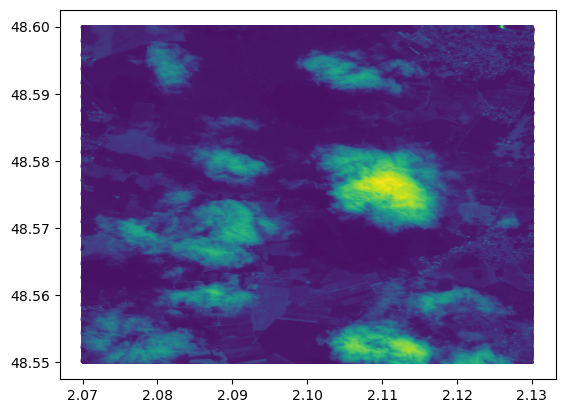

In [18]:
plt.scatter(lon, lat, c=data, s=1)

In [19]:
# reshape lat, lon, data as 2D array like cell_ids_2D_array
lat = lat.reshape(cell_ids_2D_array.shape)
lon = lon.reshape(cell_ids_2D_array.shape)
data = data.reshape(cell_ids_2D_array.shape)

In [20]:
data_resampled = resample_to_latlon_grid(lat, lon, data, method='cubic')

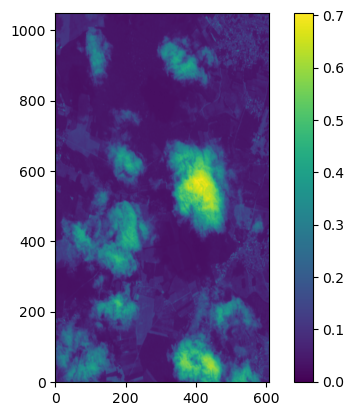

In [29]:
#plot = plt.imshow(data_resampled)
plt.imshow(data_resampled, origin="lower")
plt.colorbar()
plt.show()

In [33]:
! pip install scipy
from scipy.signal.windows import tukey

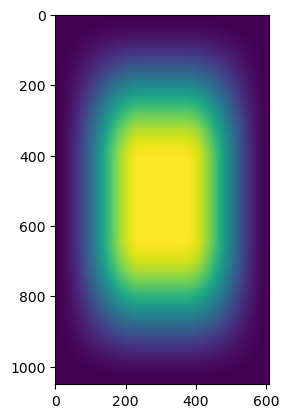

In [46]:
alpha = .8

w = tukey(data_resampled.shape[0], alpha=alpha)[:,None]*tukey(data_resampled.shape[1], alpha=alpha)[None,:]

plt.imshow(w)

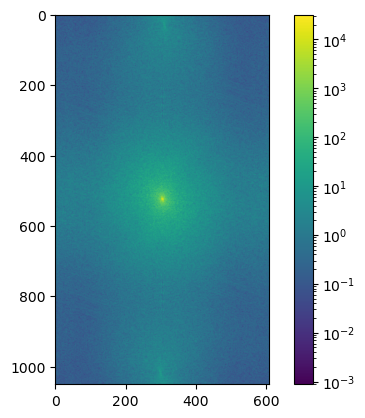

In [47]:
plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(w*data_resampled))), norm='log')
plt.colorbar()
plt.show()

In [48]:
nu, cl = ps(w*data_resampled)

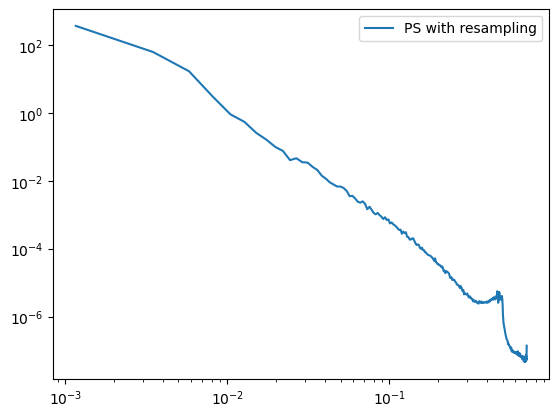

In [49]:
plt.plot(nu, cl, label='PS with resampling')
plt.yscale('log')
plt.xscale('log')
plt.legend()